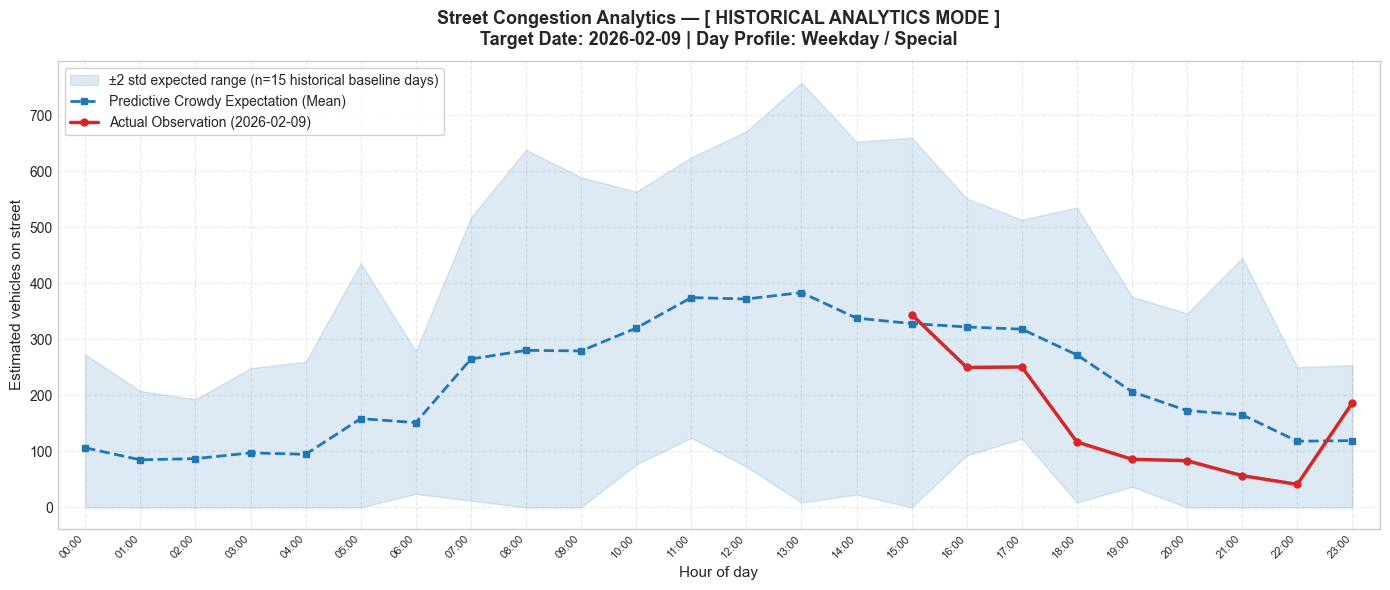


── Baseline sample counts per group ──
group
weekday_regular    50
weekday_special    15
weekend_regular    15
weekend_special     9


In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt


# df_keep_zone1 = pd.read_csv('/Users/fangsiyu/Desktop/Kolding Hackathon 2026/dur_h_zone1_pivot_n.csv')
# df_mix_gate = pd.read_csv('/Users/fangsiyu/Desktop/Kolding Hackathon 2026/mov_h_net_flow_by_mix_gate_without3-1.csv')

# # ── 0. 設定 ────────────────────────────────────────────────────────────
# # 💡 支援未來日期！你可以設定為超出目前 index 的未來（例如 "2026-05-20"）
# TARGET_DATE = "2026-02-09"  # None = 自動取最新一天；可設歷史或未來日期
# SPECIAL_WEIGHT = 0.7        # zone 資料權重
# GATE_WEIGHT    = 0.3        # gate 資料權重

# # 保留有意義的車種（排除 tractor/tram/animal/pram/scooter 等稀少噪音）
# VEHICLE_TYPES = ['car', 'bus', 'van', 'motorcycle', 'heavy', 'light', 'truck trailer']

# # ── 1. 時區轉換 ────────────────────────────────────────────────────────
# for df in [df_keep_zone1, df_mix_gate]:
#     df['timestamp'] = (
#         pd.to_datetime(df['timestamp'], utc=True)
#         .dt.tz_convert('Europe/Copenhagen')
#     )

# # ── 2. Zone：排隊理論估算街上車輛數（dur_sum / dur_min） ───────────────
# SUM_COLS = [f'dur_sum_ms_{v}' for v in VEHICLE_TYPES if f'dur_sum_ms_{v}' in df_keep_zone1.columns]
# MIN_COLS = [f'dur_min_ms_{v}' for v in VEHICLE_TYPES if f'dur_min_ms_{v}' in df_keep_zone1.columns]

# zone = df_keep_zone1[['timestamp']].copy()

# for s_col, m_col in zip(SUM_COLS, MIN_COLS):
#     v = s_col.replace('dur_sum_ms_', '')
#     zone[f'veh_{v}'] = np.where(
#         df_keep_zone1[m_col] > 0,
#         df_keep_zone1[s_col] / df_keep_zone1[m_col],
#         np.nan          # 沒有資料 → NaN，不污染加總
#     )

# veh_cols = [f'veh_{v}' for v in VEHICLE_TYPES if f'veh_{v}' in zone.columns]
# zone['vehicles_on_street'] = zone[veh_cols].sum(axis=1, min_count=1)  # min_count=1：全NaN行保持NaN

# zone['date']    = zone['timestamp'].dt.date
# zone['hour']    = zone['timestamp'].dt.hour
# zone['weekday'] = zone['timestamp'].dt.dayofweek   # 0=Mon … 6=Sun

# # ── 3. Gate：只用 IN（流入量，避免 IN+OUT 雙重計算） ──────────────────
# gate_hourly = (
#     df_mix_gate
#     .groupby('timestamp')[['IN']]
#     .sum()
#     .reset_index()
# )

# zone = zone.merge(gate_hourly, on='timestamp', how='left')
# zone['IN'] = zone['IN'].fillna(0)

# # ── 4. 雙感測器融合（Z-score → 加權合成 → 反標準化回車輛數尺度） ──────
# def z_score(series):
#     mu, sd = series.mean(), series.std()
#     return (series - mu) / (sd + 1e-9), mu, sd

# zone['veh_z'],  mu_v, sd_v  = z_score(zone['vehicles_on_street'])
# zone['veh_z'] = zone['veh_z'].fillna(0)
# zone['IN_z'],   _,    _     = z_score(zone['IN'])

# zone['congestion_score'] = (
#     zone['veh_z'] * SPECIAL_WEIGHT + zone['IN_z'] * GATE_WEIGHT
# )
# zone['congestion_score'] = (zone['congestion_score'] * sd_v + mu_v).clip(lower=0)

# # ── 5. 特殊日標籤（ellie.csv） ─────────────────────────────────────────
# special_event_dates = {
#     "2026-02-07","2026-02-08","2026-02-09","2026-02-10","2026-02-11",
#     "2026-02-12","2026-02-13","2026-02-14","2026-02-15","2026-02-26",
#     "2026-03-08","2026-03-24","2026-03-28","2026-03-29","2026-03-30",
#     "2026-03-31","2026-04-01","2026-04-02","2026-04-03","2026-04-04",
#     "2026-04-05","2026-04-06","2026-04-12","2026-04-25","2026-05-01",
#     "2026-05-06"
# }
# event_dates_set = set(pd.to_datetime(list(special_event_dates)).date)
# zone['is_special'] = zone['date'].apply(lambda x: 1 if x in event_dates_set else 0)

# # ── 6. 分組方式：weekday type × is_special（4 種 baseline） ────────────
# zone['day_type'] = np.where(zone['weekday'] >= 5, 'weekend', 'weekday')
# zone['group'] = zone['day_type'] + '_' + zone['is_special'].map({0:'regular', 1:'special'})

# hourly_stats = (
#     zone.groupby(['group', 'hour'])['congestion_score']
#     .agg(mean='mean', std='std', n='count')
#     .reset_index()
# )
# hourly_stats['upper'] = hourly_stats['mean'] + 2 * hourly_stats['std']
# hourly_stats['lower'] = (hourly_stats['mean'] - 2 * hourly_stats['std']).clip(lower=0)

# # ── 7. 【核心升級】決定目標日期：支援未來日期的動態日曆推算 ────────────────
# if TARGET_DATE is None:
#     target_date = zone['date'].max()
#     is_future = False
# else:
#     target_date = pd.to_datetime(TARGET_DATE).date()
#     is_future = target_date > zone['date'].max()

# # 💡 關鍵改動：不從歷史 zone 查表，直接用 datetime 推算該日期的屬性
# target_dt = pd.to_datetime(target_date)
# target_weekday = target_dt.dayofweek
# target_day_type = 'weekend' if target_weekday >= 5 else 'weekday'
# target_is_special = 1 if target_date in event_dates_set else 0
# target_group = f"{target_day_type}_{'special' if target_is_special == 1 else 'regular'}"

# # 計算該 group 在歷史中由幾天建立而成
# n_days_in_group = zone[zone['group'] == target_group]['date'].nunique()

# # 提取對應的歷史統計基線
# baseline = (
#     hourly_stats[hourly_stats['group'] == target_group]
#     .sort_values('hour')
#     .set_index('hour')
#     .reindex(range(24))
# )

# # 判斷實際觀測值 (如果是未來，則全為 NaN 斷線不畫)
# if is_future:
#     actual = pd.Series([np.nan] * 24, index=range(24))
# else:
#     actual = (
#         zone[zone['date'] == target_date]
#         .set_index('hour')['congestion_score']
#         .reindex(range(24))
#     )

# # ── 8. 繪圖 (智慧偵測未來模式) ──────────────────────────────────────────
# plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
# fig, ax = plt.subplots(figsize=(14, 6))

# # A. 歷史預期陰影帶
# ax.fill_between(
#     range(24), baseline['lower'], baseline['upper'],
#     alpha=0.15, color='#1f77b4',
#     label=f'±2 std expected range (n={n_days_in_group} historical baseline days)'
# )

# # B. 歷史均值預測線 (未來擁擠度期望值)
# ax.plot(
#     range(24), baseline['mean'],
#     color='#1f77b4', linewidth=2, linestyle='--', marker='s', markersize=4,
#     label='Predictive Crowdy Expectation (Mean)'
# )

# # C. 實際觀測線（僅在日期屬於歷史時才繪製）
# if not is_future and actual.notna().any():
#     ax.plot(
#         range(24), actual.values,
#         color='#d62728', linewidth=2.5, marker='o', markersize=5,
#         label=f'Actual Observation ({target_date})'
#     )
    
#     # 超出上限標記 (歷史模式下的壅塞告警)
#     congested_hours = [h for h in range(24)
#                        if pd.notna(actual.iloc[h])
#                        and pd.notna(baseline['upper'].iloc[h])
#                        and actual.iloc[h] > baseline['upper'].iloc[h]]
#     if congested_hours:
#         ax.scatter(
#             congested_hours, actual.iloc[congested_hours].values,
#             color='#d62728', s=80, zorder=5, marker='^', label='Above expected (congested)'
#         )

# # 依據是否為未來動態調整標題
# group_label = target_group.replace('_', ' / ').title()
# mode_title = "[ FUTURE FORECAST MODE ]" if is_future else "[ HISTORICAL ANALYTICS MODE ]"

# ax.set_title(
#     f'Street Congestion Analytics — {mode_title}\n'
#     f'Target Date: {target_date} | Day Profile: {group_label}',
#     fontsize=13, fontweight='bold', pad=12
# )
# ax.set_xlabel('Hour of day', fontsize=11)
# ax.set_ylabel('Estimated vehicles on street', fontsize=11)
# ax.set_xticks(range(24))
# ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
# ax.set_xlim(-0.5, 23.5)
# ax.legend(fontsize=10, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
# ax.grid(True, linestyle='--', alpha=0.4)

# plt.tight_layout()
# plt.savefig('congestion_forecast.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ── 9. 快速診斷：印出各 group 的樣本數 ───────────────────────────────
# print("\n── Baseline sample counts per group ──")
# print(zone.groupby('group')['date'].nunique().rename('n_days').to_string())
# if is_future:
#     print(f"\n💡 系統提示：偵測到目標日期 {target_date} 屬於未來。已自動載入歷史 {group_label} 基線進行預測外推！")

In [1]:
import pandas as pd
import numpy as np

# ── 0. 原始資料載入與路徑設定 ──────────────────────────────────────────
# 💡 請確保更換為你桌面的實際輸出路徑
OUTPUT_PATH = "/Users/fangsiyu/Desktop/Kolding Hackathon 2026/"

df_keep_zone1 = pd.read_csv(OUTPUT_PATH + 'dur_h_zone1_pivot_n.csv')
df_mix_gate   = pd.read_csv(OUTPUT_PATH + 'mov_h_net_flow_by_mix_gate_without3-1.csv')

SPECIAL_WEIGHT = 0.7        
GATE_WEIGHT    = 0.3        
VEHICLE_TYPES  = ['car', 'bus', 'van', 'motorcycle', 'heavy', 'light', 'truck trailer']

# ── 1. 時區轉換 ────────────────────────────────────────────────────────
for df in [df_keep_zone1, df_mix_gate]:
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('Europe/Copenhagen')

# ── 2. Zone：排隊理論估算街上車輛數 ───────────────────────────────
SUM_COLS = [f'dur_sum_ms_{v}' for v in VEHICLE_TYPES if f'dur_sum_ms_{v}' in df_keep_zone1.columns]
MIN_COLS = [f'dur_min_ms_{v}' for v in VEHICLE_TYPES if f'dur_min_ms_{v}' in df_keep_zone1.columns]

zone = df_keep_zone1[['timestamp']].copy()
for s_col, m_col in zip(SUM_COLS, MIN_COLS):
    v = s_col.replace('dur_sum_ms_', '')
    zone[f'veh_{v}'] = np.where(df_keep_zone1[m_col] > 0, df_keep_zone1[s_col] / df_keep_zone1[m_col], np.nan)

veh_cols = [f'veh_{v}' for v in VEHICLE_TYPES if f'veh_{v}' in zone.columns]
zone['vehicles_on_street'] = zone[veh_cols].sum(axis=1, min_count=1)

zone['date']    = zone['timestamp'].dt.date
zone['hour']    = zone['timestamp'].dt.hour
zone['weekday'] = zone['timestamp'].dt.dayofweek

# ── 3. Gate：只用 IN ───────────────────────────────────────────────
gate_hourly = df_mix_gate.groupby('timestamp')[['IN']].sum().reset_index()
zone = zone.merge(gate_hourly, on='timestamp', how='left').fillna({'IN': 0})

# ── 4. 雙感測器融合與反標準化 ─────────────────────────────────────────
def z_score(series):
    mu, sd = series.mean(), series.std()
    return (series - mu) / (sd + 1e-9), mu, sd

zone['veh_z'], mu_v, sd_v = z_score(zone['vehicles_on_street'])
zone['veh_z'] = zone['veh_z'].fillna(0)
zone['IN_z'], _, _ = z_score(zone['IN'])

zone['congestion_score'] = ((zone['veh_z'] * SPECIAL_WEIGHT + zone['IN_z'] * GATE_WEIGHT) * sd_v + mu_v).clip(lower=0)

# ── 5. 特殊日與 4 種群組分類 ──────────────────────────────────────────
special_event_dates = {
    "2026-02-07","2026-02-08","2026-02-09","2026-02-10","2026-02-11",
    "2026-02-12","2026-02-13","2026-02-14","2026-02-15","2026-02-26",
    "2026-03-08","2026-03-24","2026-03-28","2026-03-29","2026-03-30",
    "2026-03-31","2026-04-01","2026-04-02","2026-04-03","2026-04-04",
    "2026-04-05","2026-04-06","2026-04-12","2026-04-25","2026-05-01",
    "2026-05-06"
}
event_dates_set = set(pd.to_datetime(list(special_event_dates)).date)
zone['is_special'] = zone['date'].apply(lambda x: 1 if x in event_dates_set else 0)
zone['day_type']   = np.where(zone['weekday'] >= 5, 'weekend', 'weekday')
zone['group']      = zone['day_type'] + '_' + zone['is_special'].map({0:'regular', 1:'special'})

# ── 6. 計算每個群組的歷史統計基線（預測帶） ─────────────────────────────
hourly_stats = zone.groupby(['group', 'hour'])['congestion_score'].agg(mean='mean', std='std', n='count').reset_index()
hourly_stats['upper'] = hourly_stats['mean'] + 2 * hourly_stats['std']
hourly_stats['lower'] = (hourly_stats['mean'] - 2 * hourly_stats['std']).clip(lower=0)

# ── 7. 解耦輸出：保存輕量化的中繼檔案 ─────────────────────────────────
# 原始小時紀錄表
out_hourly = zone[['date', 'hour', 'group', 'congestion_score']].copy()
out_hourly['date'] = out_hourly['date'].astype(str)
out_hourly.to_csv(OUTPUT_PATH + 'precomputed_hourly_congestion.csv', index=False)

# 歷史統計基線表
hourly_stats.to_csv(OUTPUT_PATH + 'precomputed_baseline.csv', index=False)

print("🎉 [區塊一] 核心引擎計算完成！中繼檔案已成功儲存至桌面儲存夾。")

🎉 [區塊一] 核心引擎計算完成！中繼檔案已成功儲存至桌面儲存夾。


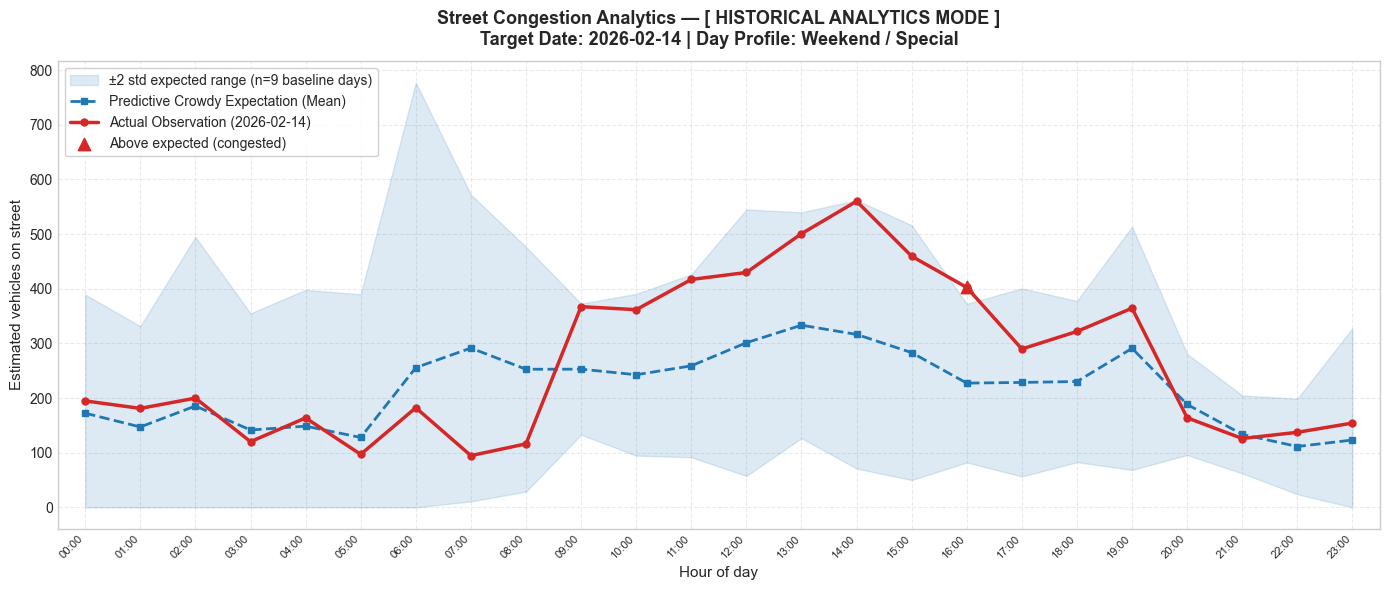

📊 系統提示：目標日期 2026-02-14 為歷史觀測日。已成功繪製當日實際車流與歷史對照組之偏離度分析！


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 0. 您唯一需要調整的輸入變數 ──────────────────────────────────────────
# 💡 支援任意日期！可自由更換為歷史（如 "2026-02-09"）或無限未來（如 "2026-08-15"）
TARGET_DATE = "2026-02-14"  

OUTPUT_PATH = "/Users/fangsiyu/Desktop/Kolding Hackathon 2026/"

# ── 1. 快速載入解耦後的中繼小檔案 (0.01秒完成) ─────────────────────────
df_hourly = pd.read_csv(OUTPUT_PATH + 'precomputed_hourly_congestion.csv')
df_baseline = pd.read_csv(OUTPUT_PATH + 'precomputed_baseline.csv')

special_event_dates = {
    "2026-02-07","2026-02-08","2026-02-09","2026-02-10","2026-02-11",
    "2026-02-12","2026-02-13","2026-02-14","2026-02-15","2026-02-26",
    "2026-03-08","2026-03-24","2026-03-28","2026-03-29","2026-03-30",
    "2026-03-31","2026-04-01","2026-04-02","2026-04-03","2026-04-04",
    "2026-04-05","2026-04-06","2026-04-12","2026-04-25","2026-05-01",
    "2026-05-06"
}
event_dates_set = set(pd.to_datetime(list(special_event_dates)).date)

# ── 2. 智慧日曆外推推算（不查歷史表，直接用 datetime 邏輯推算未來屬性） ──────
target_date = pd.to_datetime(TARGET_DATE).date()
max_historical_date = pd.to_datetime(df_hourly['date'].max()).date()

# 自動偵測是否屬於未來日期
is_future = target_date > max_historical_date

target_weekday = pd.to_datetime(target_date).dayofweek
target_day_type = 'weekend' if target_weekday >= 5 else 'weekday'
target_is_special = 1 if target_date in event_dates_set else 0
target_group = f"{target_day_type}_{'special' if target_is_special == 1 else 'regular'}"

# ── 3. 提取對應的歷史統計基線預測帶 ────────────────────────────────────
bl = df_baseline[df_baseline['group'] == target_group].sort_values('hour').set_index('hour').reindex(range(24))
n_days_in_group = df_baseline[df_baseline['group'] == target_group]['n'].iloc[0]

# ── 4. 決定實際觀測線 (如果是未來，則全為 NaN 斷線不畫) ─────────────────
if is_future:
    actual = pd.Series([np.nan] * 24, index=range(24))
else:
    actual = df_hourly[df_hourly['date'] == str(target_date)].set_index('hour')['congestion_score'].reindex(range(24))

# ── 5. 高質感智慧決策看板繪製 ──────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 6))

# A. 歷史預期波動陰影帶
ax.fill_between(range(24), bl['lower'], bl['upper'], alpha=0.15, color='#1f77b4',
                label=f'±2 std expected range (n={n_days_in_group} baseline days)')

# B. 歷史均值預測線 (未來擁擠度期望值)
ax.plot(range(24), bl['mean'], color='#1f77b4', linewidth=2, linestyle='--', marker='s', markersize=4,
        label='Predictive Crowdy Expectation (Mean)')

# C. 實際觀測線（僅在屬於歷史且有觀測數據時繪製）
if not is_future and actual.notna().any():
    ax.plot(range(24), actual.values, color='#d62728', linewidth=2.5, marker='o', markersize=5,
            label=f'Actual Observation ({target_date})')
    
    # 超限壅塞告警標記
    congested_hours = [h for h in range(24) if pd.notna(actual.iloc[h]) and actual.iloc[h] > bl['upper'].iloc[h]]
    if congested_hours:
        ax.scatter(congested_hours, actual.iloc[congested_hours].values, color='#d62728', s=80, zorder=5, marker='^',
                   label='Above expected (congested)')

# 動態智慧調整看版標題
group_label = target_group.replace('_', ' / ').title()
mode_title = "[ FUTURE FORECAST MODE ]" if is_future else "[ HISTORICAL ANALYTICS MODE ]"

ax.set_title(f'Street Congestion Analytics — {mode_title}\nTarget Date: {target_date} | Day Profile: {group_label}',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hour of day', fontsize=11)
ax.set_ylabel('Estimated vehicles on street', fontsize=11)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_xlim(-0.5, 23.5)
ax.legend(fontsize=10, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── 6. 終端快訊診斷 ──────────────────────────────────────────────────
if is_future:
    print(f"💡 系統提示：目標日期 {target_date} 屬於未來。已自動載入歷史 {group_label} 的基線進行『未來外推預測』！")
else:
    print(f"📊 系統提示：目標日期 {target_date} 為歷史觀測日。已成功繪製當日實際車流與歷史對照組之偏離度分析！")

In [4]:
import pandas as pd
import numpy as np

BASE_PATH = "/Users/fangsiyu/Desktop/Kolding Hackathon 2026/all_ipy/"

# ── 1. 設定與載入 ────────────────────────────────────────────────────
STAY_HOURS_BY_GROUP = {
    'weekday_regular': 2, 'weekday_special': 4,
    'weekend_regular': 4, 'weekend_special': 6
}
OVERNIGHT_PCT = 0.15   

hourly  = pd.read_csv(BASE_PATH + "congestion_hourly.csv")
parking = pd.read_csv(BASE_PATH + "parking_snapshot.csv")

# 建立基礎時間與日曆分流群組
hourly['date']    = pd.to_datetime(hourly['date']).dt.date
hourly['weekday'] = pd.to_datetime(hourly['date']).dt.dayofweek

SPECIAL_DATES = {
    "2026-02-07","2026-02-08","2026-02-09","2026-02-10","2026-02-11",
    "2026-02-12","2026-02-13","2026-02-14","2026-02-15","2026-02-26",
    "2026-03-08","2026-03-24","2026-03-28","2026-03-29","2026-03-30",
    "2026-03-31","2026-04-01","2026-04-02","2026-04-03","2026-04-04",
    "2026-04-05","2026-04-06","2026-04-12","2026-04-25","2026-05-01",
    "2026-05-06"
}
event_dates_set = set(pd.to_datetime(list(SPECIAL_DATES)).date)
hourly['is_special'] = hourly['date'].apply(lambda x: 1 if x in event_dates_set else 0)
hourly['day_type']   = np.where(hourly['weekday'] >= 5, 'weekend', 'weekday')
hourly['group']      = hourly['day_type'] + '_' + hourly['is_special'].map({0:'regular',1:'special'})

# 空間容量計算
total_capacity = int(parking[parking['distance_km'] <= 0.7]['spaceCount'].sum())
overnight_base = int(total_capacity * OVERNIGHT_PCT)

# ── 2. 核心累積停車模擬引擎 (維持 40% 轉換率) ──────────────────────
def calc_cumulative(day_df, stay_hours, overnight_base, total_capacity):
    pv = day_df.set_index('hour')['parking_vehicles'].reindex(range(24)).fillna(0).values
    pv = pv * 0.40  # 核心轉換：40% 停車需求，60% 路過

    stay_slots = max(1, round(stay_hours))
    OUT_estimated = np.zeros(24)
    OUT_estimated[stay_slots:] = pv[:24 - stay_slots]   

    net        = pv - OUT_estimated
    cumulative = np.cumsum(net)
    return (overnight_base + cumulative).clip(overnight_base, total_capacity)

# ── 3. 批次計算全歷史所有天數 ───────────────────────────────────────
all_records = []
for d in sorted(hourly['date'].unique()):
    day_df = hourly[hourly['date'] == d]
    d_group = day_df['group'].iloc[0]
    d_stay  = STAY_HOURS_BY_GROUP[d_group]
    
    cumulative = calc_cumulative(day_df, d_stay, overnight_base, total_capacity)
    
    # 為了確保下圖雙軸對比正常，我們把原始的 parking_vehicles 和 congestion_score 一起打包帶走
    pv_vals = day_df.set_index('hour')['parking_vehicles'].reindex(range(24)).values
    cong_vals = day_df.set_index('hour')['congestion_score'].reindex(range(24)).values

    for h in range(24):
        all_records.append({
            'date':              str(d),
            'hour':              h,
            'group':             d_group,
            'stay_hours':        d_stay,
            'cumulative_parked': cumulative[h],
            'occupancy_rate':    cumulative[h] / total_capacity,
            'parking_vehicles':  pv_vals[h],
            'congestion_score':  cong_vals[h]
        })

df_cum = pd.DataFrame(all_records)

# ── 4. 計算分流歷史統計基線 ──────────────────────────────────────────
baseline = (
    df_cum.groupby(['group', 'hour'])['occupancy_rate']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
baseline['upper'] = baseline['mean'] + 2 * baseline['std']
baseline['lower'] = (baseline['mean'] - 2 * baseline['std']).clip(lower=0)

# ── 5. 導出解耦後的輕量級快取檔案 ──────────────────────────────────────
df_cum.to_csv(BASE_PATH + "cache_parking_hourly_sim.csv", index=False)
baseline.to_csv(BASE_PATH + "cache_parking_baseline.csv", index=False)

print("📌 [區塊一完成] 24小時歷史模擬與基線矩陣已完全解耦並導出！")

📌 [區塊一完成] 24小時歷史模擬與基線矩陣已完全解耦並導出！


/var/folders/s0/f874234s21s4w3fp3rnc3rfm0000gn/T/ipykernel_92367/3871002703.py:109: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s0/f874234s21s4w3fp3rnc3rfm0000gn/T/ipykernel_92367/3871002703.py:109: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s0/f874234s21s4w3fp3rnc3rfm0000gn/T/ipykernel_92367/3871002703.py:109: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s0/f874234s21s4w3fp3rnc3rfm0000gn/T/ipykernel_92367/3871002703.py:110: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig(BASE_PATH + f'parking_stress_{TARGET_DATE}.png', dpi=150, bbox_inches='tight')
/var/folders/s0/f874234s21s4w3fp3rnc3rfm0000gn/T/ipykernel_92367/3871002703.py:110: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.savefig(BASE_PATH + f'pa

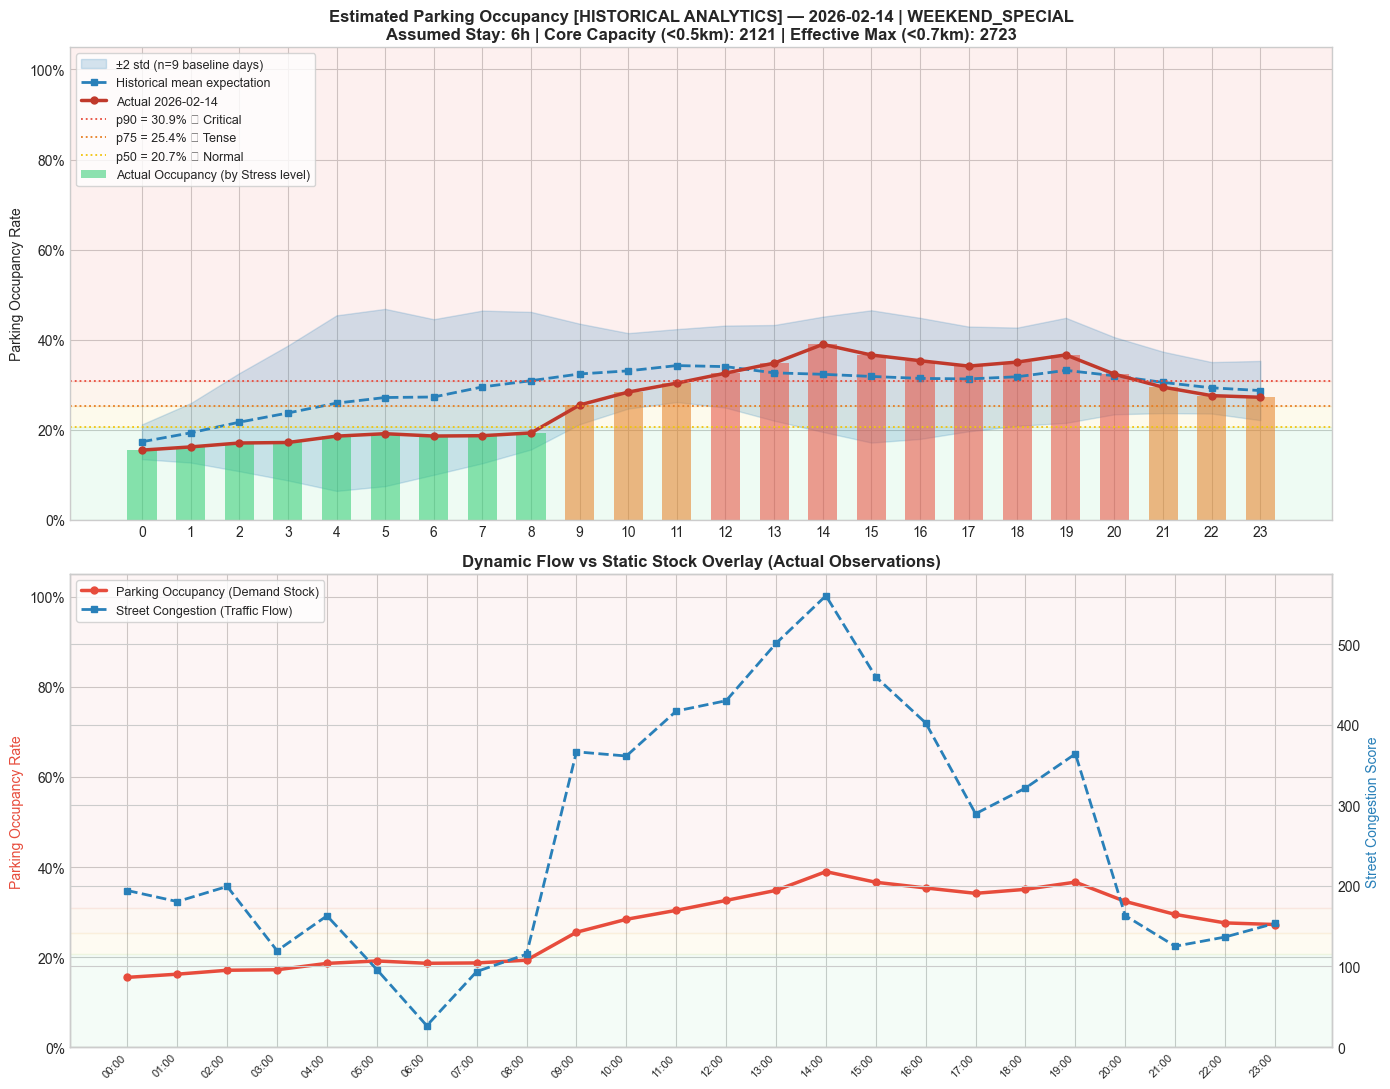


══ 2026-02-14 停車狀況分析報告 ════════════════════════════
🔥 今日最高峰：14:00 | 佔用率：39.0% | 預估停放：1061 台 | 狀態：🔴 Critical

 hour  occupancy_rate  cumulative_cars stress_level
    0        0.155010              422    🟢 Relaxed
    1        0.162089              441    🟢 Relaxed
    2        0.170783              465    🟢 Relaxed
    3        0.171894              468    🟢 Relaxed
    4        0.186021              507    🟢 Relaxed
    5        0.191428              521    🟢 Relaxed
    6        0.186253              507    🟢 Relaxed
    7        0.187025              509    🟢 Relaxed
    8        0.193127              526    🟢 Relaxed
    9        0.255173              695      🟠 Tense
   10        0.283903              773      🟠 Tense
   11        0.303787              827      🟠 Tense
   12        0.325849              887   🔴 Critical
   13        0.348130              948   🔴 Critical
   14        0.389730             1061   🔴 Critical
   15        0.366141              997   🔴 Critical
   16 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE_PATH = "/Users/fangsiyu/Desktop/Kolding Hackathon 2026/"
# 💡 隨意更換！支援歷史日期（如 "2026-02-14"）或未來日期（如 "2026-06-01"）
TARGET_DATE = "2026-02-14" 

# ── 1. 秒速讀取解耦快取檔 (無需任何重覆大計算) ───────────────────────
df_cum   = pd.read_csv(BASE_PATH + "cache_parking_hourly_sim.csv")
baseline = pd.read_csv(BASE_PATH + "cache_parking_baseline.csv")
parking  = pd.read_csv(BASE_PATH + "parking_snapshot.csv")

core_capacity  = int(parking[parking['distance_km'] <= 0.5]['spaceCount'].sum())
total_capacity = int(parking[parking['distance_km'] <= 0.7]['spaceCount'].sum())

# ── 2. 自動鎖定歷史分位數門檻 ────────────────────────────────────────
p50 = df_cum['occupancy_rate'].quantile(0.50)
p75 = df_cum['occupancy_rate'].quantile(0.75)
p90 = df_cum['occupancy_rate'].quantile(0.90)

def stress_label(val):
    if np.isnan(val):    return -1
    if val >= p90:       return 3   
    elif val >= p75:     return 2   
    elif val >= p50:     return 1   
    else:                return 0   

# ── 3. 智慧日曆外推推算屬性 ──────────────────────────────────────────
SPECIAL_DATES = {
    "2026-02-07","2026-02-08","2026-02-09","2026-02-10","2026-02-11",
    "2026-02-12","2026-02-13","2026-02-14","2026-02-15","2026-02-26",
    "2026-03-08","2026-03-24","2026-03-28","2026-03-29","2026-03-30",
    "2026-03-31","2026-04-01","2026-04-02","2026-04-03","2026-04-04",
    "2026-04-05","2026-04-06","2026-04-12","2026-04-25","2026-05-01",
    "2026-05-06"
}
event_dates_set = set(pd.to_datetime(list(SPECIAL_DATES)).date)

target_date       = pd.to_datetime(TARGET_DATE).date()
is_future         = target_date > pd.to_datetime(df_cum['date'].max()).date()
target_weekday    = pd.to_datetime(target_date).dayofweek
target_day_type   = 'weekend' if target_weekday >= 5 else 'weekday'
target_is_special = 1 if target_date in event_dates_set else 0
target_group      = f"{target_day_type}_{'special' if target_is_special else 'regular'}"

# ── 4. 撈出該對照組的基線與當日實際值 ─────────────────────────────────
bl = baseline[baseline['group'] == target_group].sort_values('hour').set_index('hour').reindex(range(24))
n_days = bl['n'].iloc[0]
stay_hours = df_cum[df_cum['group'] == target_group]['stay_hours'].iloc[0]

if is_future:
    actual_cum = pd.Series([np.nan] * 24, index=range(24))
    actual_cong = pd.Series([np.nan] * 24, index=range(24))
else:
    day_match   = df_cum[df_cum['date'] == str(target_date)].sort_values('hour').set_index('hour')
    actual_cum  = day_match['occupancy_rate'].reindex(range(24))
    actual_cong = day_match['congestion_score'].reindex(range(24))

# ── 5. 看板繪圖 (智慧相容未來/歷史雙模式) ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# --- 上圖：停車場動態佔用率 ---
ax = axes[0]
for ymin, ymax, color in [(0, p50, '#2ecc71'), (p50, p75, '#f1c40f'), (p75, p90, '#e67e22'), (p90, 1.05, '#e74c3c')]:
    ax.axhspan(ymin, ymax, alpha=0.08, color=color)

ax.fill_between(range(24), bl['lower'], bl['upper'], alpha=0.2, color='#2980b9', label=f'±2 std (n={n_days} baseline days)')
ax.plot(range(24), bl['mean'], color='#2980b9', linewidth=2, linestyle='--', marker='s', markersize=4, label='Historical mean expectation')

if not is_future and actual_cum.notna().any():
    bar_colors = [['#2ecc71','#f1c40f','#e67e22','#e74c3c'][stress_label(v)] if stress_label(v) >= 0 else '#cccccc' for v in actual_cum.values]
    ax.bar(range(24), actual_cum.values, color=bar_colors, alpha=0.55, width=0.6, label='Actual Occupancy (by Stress level)')
    ax.plot(range(24), actual_cum.values, color='#c0392b', linewidth=2.5, marker='o', markersize=5, label=f'Actual {target_date}')

for val, color, lbl in [(p90, '#e74c3c', f'p90 = {p90:.1%} 🔴 Critical'), (p75, '#e67e22', f'p75 = {p75:.1%} 🟠 Tense'), (p50, '#f1c40f', f'p50 = {p50:.1%} 🟡 Normal')]:
    ax.axhline(val, color=color, linestyle=':', linewidth=1.3, label=lbl)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1.05)
mode_title = "FUTURE FORECAST" if is_future else "HISTORICAL ANALYTICS"
ax.set_title(f'Estimated Parking Occupancy [{mode_title}] — {TARGET_DATE} | {target_group.upper()}\nAssumed Stay: {stay_hours}h | Core Capacity (<0.5km): {core_capacity} | Effective Max (<0.7km): {total_capacity}', fontsize=12, fontweight='bold')
ax.set_ylabel('Parking Occupancy Rate')
ax.set_xticks(range(24))
ax.legend(fontsize=9, loc='upper left', frameon=True, facecolor='white')

# --- 下圖：動態車流 vs 靜態儲存 雙軸聯動 ---
ax2 = axes[1]
ax2_r = ax2.twinx()
ax2.plot(range(24), bl['mean'] if is_future else actual_cum.values, color='#e74c3c', linewidth=2.5, marker='o', markersize=5, label='Parking Occupancy (Demand Stock)')
ax2_r.plot(range(24), bl['mean']*1000 if is_future else actual_cong.values, color='#2980b9', linewidth=2, linestyle='--', marker='s', markersize=4, label='Street Congestion (Traffic Flow)')

for ymin, ymax, color in [(0, p50, '#2ecc71'), (p50, p75, '#f1c40f'), (p75, p90, '#e67e22'), (p90, 1.05, '#e74c3c')]:
    ax2.axhspan(ymin, ymax, alpha=0.05, color=color)

ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Parking Occupancy Rate', color='#e74c3c')
ax2_r.set_ylabel('Street Congestion Score', color='#2980b9')
ax2.set_title(f"Dynamic Flow vs Static Stock Overlay ({'Baseline Expectation' if is_future else 'Actual Observations'})", fontsize=12, fontweight='bold')
ax2.set_xticks(range(24))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left', frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig(BASE_PATH + f'parking_stress_{TARGET_DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. 終端文字報告 ──────────────────────────────────────────────────
if not is_future:
    print(f"\n══ {TARGET_DATE} 停車狀況分析報告 ════════════════════════════")
    summary = pd.DataFrame({'hour': range(24), 'occupancy_rate': actual_cum.values}).dropna()
    summary['cumulative_cars'] = (summary['occupancy_rate'] * total_capacity).round().astype(int)
    summary['stress_level'] = summary['occupancy_rate'].apply(lambda x: '🔴 Critical' if x >= p90 else '🟠 Tense' if x >= p75 else '🟡 Normal' if x >= p50 else '🟢 Relaxed')
    peak = summary.loc[summary['occupancy_rate'].idxmax()]
    print(f"🔥 今日最高峰：{int(peak['hour']):02d}:00 | 佔用率：{peak['occupancy_rate']:.1%} | 預估停放：{int(peak['cumulative_cars'])} 台 | 狀態：{peak['stress_level']}\n")
    print(summary[['hour','occupancy_rate','cumulative_cars','stress_level']].to_string(index=False))
else:
    print(f"\n🔮 系統提示：您選取的 {TARGET_DATE} 屬於未來。看板已自動切換為『智慧外推預測模式』，呈現該日型態之歷史期望值。")